
# Proactive Thermal Anomaly Prediction Using Deep Learning
This notebook implements a proactive thermal anomaly prediction system. 
By learning temporal patterns using deep learning (LSTM/GRU), the model enables **proactive overheating prevention**, predicting anomalies *before* they happen, rather than reacting to static threshold violations.


In [1]:

!pip install kagglehub pandas numpy matplotlib seaborn scikit-learn tensorflow pillow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os
import glob
from PIL import Image
import kagglehub

# Ensure plots look good
plt.style.use('seaborn-v0_8-whitegrid')


I0000 00:00:1776486944.614974   75224 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776486944.927115   75224 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1776486948.421373   75224 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.



## 1. Data Understanding & Preprocessing
First, we programmatically download the dataset using `kagglehub`. Since the dataset contains raw thermal video frames (.jpg) rather than formatted tabular data, we will parse these images and extract statistical features representing the thermal state of the system over time. We will align these with the given frame-level anomaly annotations (.npy).


In [2]:

# Download Dataset
path = kagglehub.dataset_download("neelu1/thermal-anomaly-detection-dataset")
print("Path to dataset files:", path)

DATASET_PATH = os.path.join(path, "harbor_anomaly_dataset")
TRAIN_DIR = os.path.join(DATASET_PATH, "train")
TEST_DIR = os.path.join(DATASET_PATH, "test")
ANOMALY_DIR = os.path.join(DATASET_PATH, "test_annotations_anomalies")

def process_clip(clip_dir, is_anomaly=False, anomaly_labels=None):
    images = sorted(glob.glob(os.path.join(clip_dir, "*.jpg")))
    data = []
    
    for i, img_path in enumerate(images):
        try:
            img = Image.open(img_path).convert('L') # Grayscale
            img_arr = np.array(img)
            
            # Statistical thermal features
            mean_temp = np.mean(img_arr)
            max_temp = np.max(img_arr)
            min_temp = np.min(img_arr)
            std_temp = np.std(img_arr)
            p95_temp = np.percentile(img_arr, 95)
            
            label = 0 # Normal
            if is_anomaly and anomaly_labels is not None and i < len(anomaly_labels):
                label = int(anomaly_labels[i])
            
            data.append({
                "clip_name": os.path.basename(clip_dir),
                "frame_id": i,
                "mean_temp": mean_temp,
                "max_temp": max_temp,
                "min_temp": min_temp,
                "std_temp": std_temp,
                "p95_temp": p95_temp,
                "is_anomaly": label
            })
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            
    return data

all_data = []

print("Processing Train Data (Normal)...")
for date_dir in sorted(os.listdir(TRAIN_DIR)):
    date_path = os.path.join(TRAIN_DIR, date_dir)
    if not os.path.isdir(date_path): continue
    for clip_dir in sorted(os.listdir(date_path)):
        clip_path = os.path.join(date_path, clip_dir)
        if not os.path.isdir(clip_path): continue
        all_data.extend(process_clip(clip_path, is_anomaly=False))

print("Processing Test Data (Contains anomalies)...")
for date_dir in sorted(os.listdir(TEST_DIR)):
    date_path = os.path.join(TEST_DIR, date_dir)
    if not os.path.isdir(date_path): continue
    for clip_dir in sorted(os.listdir(date_path)):
        clip_path = os.path.join(date_path, clip_dir)
        if not os.path.isdir(clip_path): continue
        
        label_file = os.path.join(ANOMALY_DIR, date_dir, f"{clip_dir}.npy")
        anomaly_labels = None
        is_anomaly_clip = False
        if os.path.exists(label_file):
            anomaly_labels = np.load(label_file)
            is_anomaly_clip = True
            
        all_data.extend(process_clip(clip_path, is_anomaly=is_anomaly_clip, anomaly_labels=anomaly_labels))

df = pd.DataFrame(all_data)
print(f"Total frames extracted: {len(df)}")
display(df.head())


Path to dataset files: /home/jules/.cache/kagglehub/datasets/neelu1/thermal-anomaly-detection-dataset/versions/2
Processing Train Data (Normal)...


Processing Test Data (Contains anomalies)...


Total frames extracted: 39684


,clip_name,frame_id,mean_temp,max_temp,min_temp,std_temp,p95_temp,is_anomaly
0,clip_0_0941,0,75.982386,255,0,51.110755,201.0,0
1,clip_0_0941,1,76.101517,255,0,51.131221,200.0,0
2,clip_0_0941,2,76.111527,255,0,51.303131,200.0,0
3,clip_0_0941,3,76.169063,255,0,51.224800,200.0,0
4,clip_0_0941,4,76.082917,255,0,51.263364,200.0,0



## 2. Exploratory Data Analysis
Let's visualize temperature trends and the distribution of anomalies.


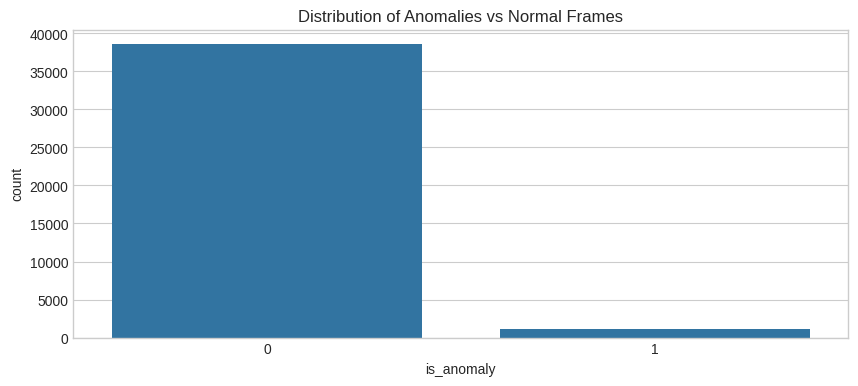

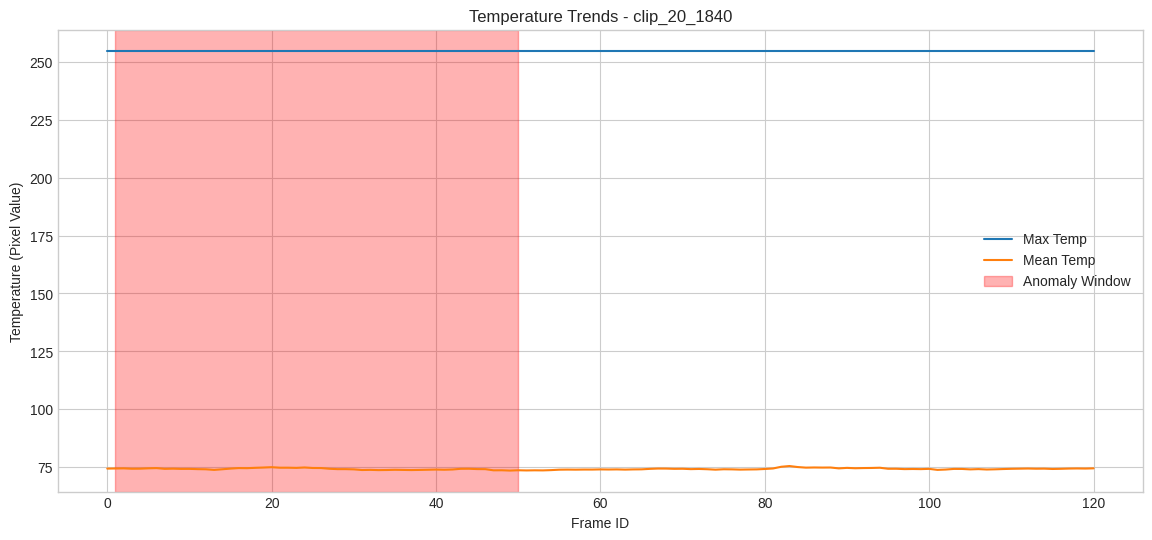

In [3]:

plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='is_anomaly')
plt.title('Distribution of Anomalies vs Normal Frames')
plt.savefig('anomaly_distribution.png')
plt.show()

# Visualize a specific anomaly clip
anomaly_clips = df[df['is_anomaly'] == 1]['clip_name'].unique()
if len(anomaly_clips) > 0:
    sample_clip = anomaly_clips[0]
else:
    sample_clip = df['clip_name'].unique()[0]

clip_data = df[df['clip_name'] == sample_clip]

plt.figure(figsize=(14, 6))
plt.plot(clip_data['frame_id'], clip_data['max_temp'], label='Max Temp')
plt.plot(clip_data['frame_id'], clip_data['mean_temp'], label='Mean Temp')
plt.fill_between(clip_data['frame_id'], 0, 1, where=clip_data['is_anomaly']==1, 
                 color='red', alpha=0.3, transform=plt.gca().get_xaxis_transform(), label='Anomaly Window')
plt.title(f'Temperature Trends - {sample_clip}')
plt.xlabel('Frame ID')
plt.ylabel('Temperature (Pixel Value)')
plt.legend()
plt.savefig('temperature_trends.png')
plt.show()



## 3. Data Preprocessing & Sequence Generation
We convert data into **time-window sequences** for temporal modeling.
To enable **proactive prediction**, we predict anomalies at time $t + k$ (prediction lead time).


In [4]:

WINDOW_SIZE = 10  # Look back 10 frames
PREDICTION_HORIZON = 5  # Predict 5 frames into the future

features = ['mean_temp', 'max_temp', 'min_temp', 'std_temp', 'p95_temp']
scaler = StandardScaler()

# Create a copy so we don't overwrite the original dataframe for later evaluation
scaled_df = df.copy()
scaled_df[features] = scaler.fit_transform(scaled_df[features])

def create_sequences(input_df, window_size, horizon):
    X, y = [], []
    for clip in input_df['clip_name'].unique():
        clip_df = input_df[input_df['clip_name'] == clip].sort_values('frame_id')
        vals = clip_df[features].values
        labels = clip_df['is_anomaly'].values
        
        for i in range(len(vals) - window_size - horizon):
            X.append(vals[i:(i + window_size)])
            # Future anomaly target
            y.append(1 if sum(labels[(i + window_size):(i + window_size + horizon)]) > 0 else 0)
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_df, WINDOW_SIZE, PREDICTION_HORIZON)
print(f"X shape: {X.shape}, y shape: {y.shape}")

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
print(f"Train set: {len(X_train)}, Val set: {len(X_val)}, Test set: {len(X_test)}")


X shape: (35394, 10, 5), y shape: (35394,)
Train set: 24775, Val set: 5309, Test set: 5310



## 4. Model Design & Training
We train an LSTM to predict future anomalies based on temporal patterns.


E0000 00:00:1776487053.385726   75224 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/jules/.pyenv/versions/3.12.13/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

...

372/388 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9675 - loss: 0.0791

377/388 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9676 - loss: 0.0791

382/388 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9676 - loss: 0.0791

387/388 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9676 - loss: 0.0790

388/388 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9693 - loss: 0.0759 - val_accuracy: 0.9714 - val_loss: 0.0693


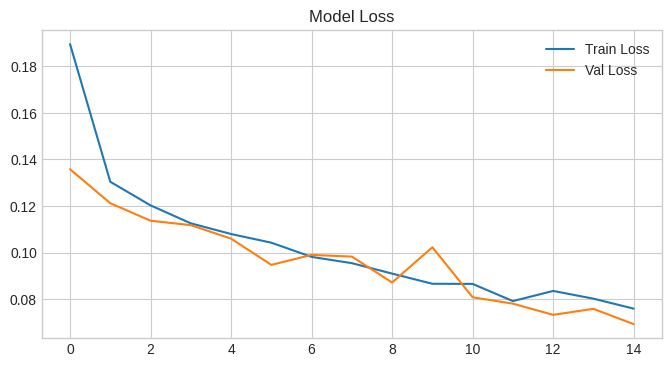

In [5]:

model = Sequential([
    LSTM(64, activation='relu', return_sequences=True, input_shape=(WINDOW_SIZE, len(features))),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()
plt.savefig('model_loss.png')
plt.show()



## 5. Baseline Comparison (Reactive vs Proactive)
**Baseline:** A simple threshold-based detection that triggers an alert only when current frame max_temp is high.
**Proactive (Ours):** Deep learning prediction of an anomaly *before* it happens.


  1/166 ━━━━━━━━━━━━━━━━━━━━ 50s 305ms/step

 19/166 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step   

 37/166 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

 55/166 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

 73/166 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

...

130/166 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

149/166 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


--- PROACTIVE DL MODEL ---
Accuracy: 0.9718
Precision: 0.7692
Recall: 0.2247
F1 Score: 0.3478
ROC AUC: 0.9741

--- REACTIVE BASELINE (Threshold-based) ---
Accuracy: 0.0283
F1 Score: 0.0551


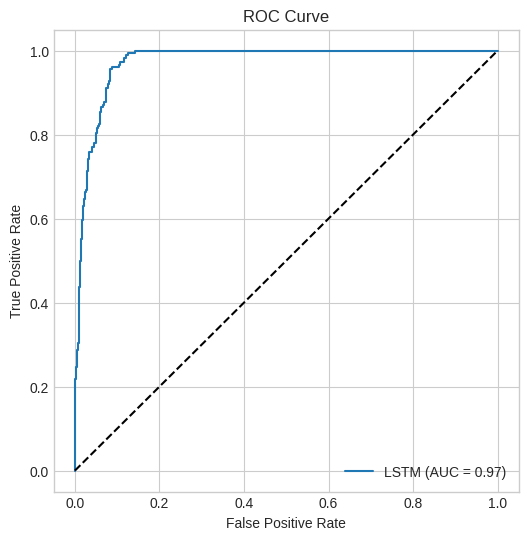

In [6]:

# Evaluate our Proactive LSTM Model
preds_prob = model.predict(X_test)
preds_class = (preds_prob > 0.5).astype(int)

print("--- PROACTIVE DL MODEL ---")
print(f"Accuracy: {accuracy_score(y_test, preds_class):.4f}")
print(f"Precision: {precision_score(y_test, preds_class):.4f}")
print(f"Recall: {recall_score(y_test, preds_class):.4f}")
print(f"F1 Score: {f1_score(y_test, preds_class):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, preds_prob):.4f}")

# Reactive Baseline (Threshold on unscaled max_temp)
# We'll say any unscaled max_temp > 250 is an anomaly
baseline_preds = (df['max_temp'] > 250).astype(int)
baseline_acc = accuracy_score(df['is_anomaly'], baseline_preds)
baseline_f1 = f1_score(df['is_anomaly'], baseline_preds)

print("\n--- REACTIVE BASELINE (Threshold-based) ---")
print(f"Accuracy: {baseline_acc:.4f}")
print(f"F1 Score: {baseline_f1:.4f}")

fpr, tpr, _ = roc_curve(y_test, preds_prob)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'LSTM (AUC = {roc_auc_score(y_test, preds_prob):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.savefig('roc_curve.png')
plt.show()



## 6. Real-Time Simulation
Simulate a streaming environment to demonstrate early warnings.


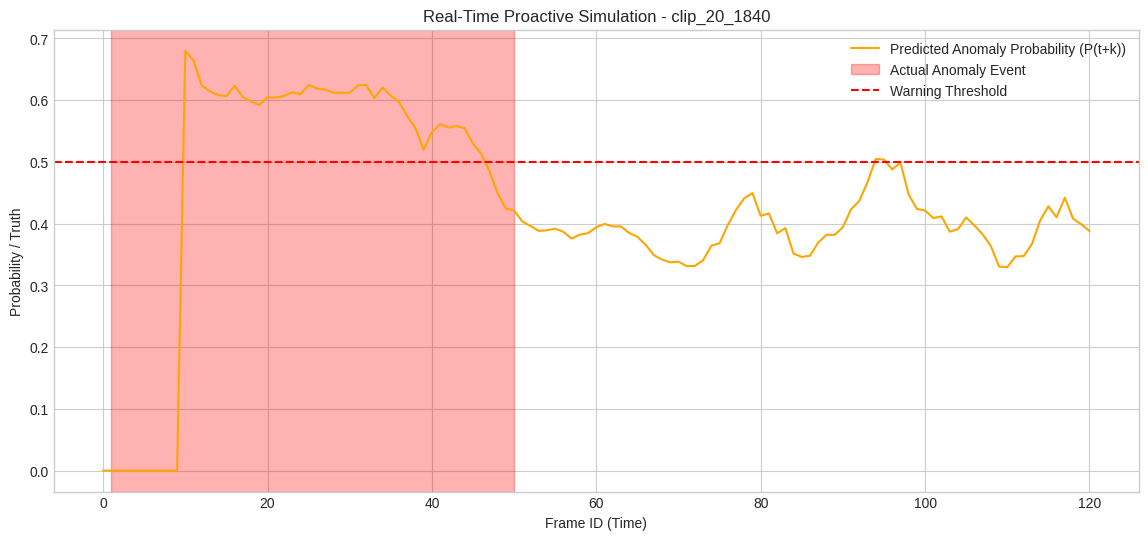

In [7]:

def simulate_stream(trained_model, clip_data, window_size):
    stream_features = clip_data[features].values
    true_labels = clip_data['is_anomaly'].values
    predictions = []
    
    for i in range(len(stream_features)):
        if i < window_size:
            predictions.append(0) # Not enough data
        else:
            window = stream_features[(i-window_size):i]
            window = np.expand_dims(window, axis=0)
            prob = trained_model.predict(window, verbose=0)[0][0]
            predictions.append(prob)
            
    return predictions, true_labels

# Pick an anomaly clip
test_clip = anomaly_clips[0] if len(anomaly_clips) > 0 else df['clip_name'].unique()[0]
scaled_clip_data = scaled_df[scaled_df['clip_name'] == test_clip].sort_values('frame_id')

probs, truths = simulate_stream(model, scaled_clip_data, WINDOW_SIZE)

plt.figure(figsize=(14, 6))
plt.plot(scaled_clip_data['frame_id'], probs, label='Predicted Anomaly Probability (P(t+k))', color='orange')
plt.fill_between(scaled_clip_data['frame_id'], 0, 1, where=np.array(truths)==1, 
                 color='red', alpha=0.3, transform=plt.gca().get_xaxis_transform(), label='Actual Anomaly Event')
plt.axhline(y=0.5, color='r', linestyle='--', label='Warning Threshold')
plt.title(f'Real-Time Proactive Simulation - {test_clip}')
plt.xlabel('Frame ID (Time)')
plt.ylabel('Probability / Truth')
plt.legend()
plt.savefig('real_time_simulation.png')
plt.show()

# Clean up zip outputs to avoid saving huge files
import shutil
try:
    shutil.rmtree(path)
except:
    pass
